In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Carga de datos (csv)

In [3]:
df = pd.read_csv('analisis_data.csv')
df.head()

,estu_tipodocumento,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_genero,cole_jornada,cole_naturaleza,estu_depto_reside,estu_genero,...,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_global,desemp,estu_edad
0,CC,URBANO,N,A,ACADÉMICO,MIXTO,TARDE,OFICIAL,BOGOTÁ,F,...,Estrato 2,1 a 2,Si,Si,Si,Si,A1,260,Medio,19.0
1,CC,URBANO,N,A,ACADÉMICO,MIXTO,TARDE,OFICIAL,BOGOTÁ,F,...,Estrato 2,1 a 2,Si,Si,Si,Si,A1,260,Medio,19.0
2,TI,URBANO,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,OFICIAL,PUTUMAYO,F,...,Estrato 1,7 a 8,No,Si,Si,Si,A1,253,Medio,19.0
3,TI,URBANO,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,OFICIAL,PUTUMAYO,F,...,Estrato 1,7 a 8,No,Si,Si,Si,A1,253,Medio,19.0
4,CC,URBANO,N,A,TÉCNICO/ACADÉMICO,MIXTO,UNICA,OFICIAL,VALLE,F,...,Estrato 2,3 a 4,No,No,No,No,A2,332,Alto,19.0


Una vez se hizo la limpieza de datos, se procede a hacer el analisis de las variables 

In [4]:
df2 = df.drop(columns=['desemp'])
df2['Ingresa'] = np.where(df2['punt_global'] >= 300, 1, 0)

In [5]:
var_cat = df2.select_dtypes(include=['object']).columns

# Clasificar las variables de acuerdo a la categoria "fami", "cole", "estu"
var_cat_cole = [col for col in var_cat if col.startswith('cole')]
var_cat_estu = [col for col in var_cat if col.startswith('estu')]
var_cat_fami = [col for col in var_cat if col.startswith('fami')]

# El desempeño de ingles se agrega a la categoria de "estu"
var_cat_estu.append('desemp_ingles')
var_num = 'estu_edad'
target = 'punt_global'

#### Boxplots y mapas de calor entre las variables que corresponde al colegio

Como se discretizo la variable `punt_global` de acuerdo a los cuantiles se procede a hacer dos tipos de graficos. Primero es importante notar que todas las variables que componen a X son discretas, por lo que para la visualización de los datos se realizara dos tipos de graficos. Un Boxplot para comparar las variables categoricas y y el `punt_global`. En segundo lugar, se hara un mapa de calor para la variable `desemp`. Que es la variable categorica de interes

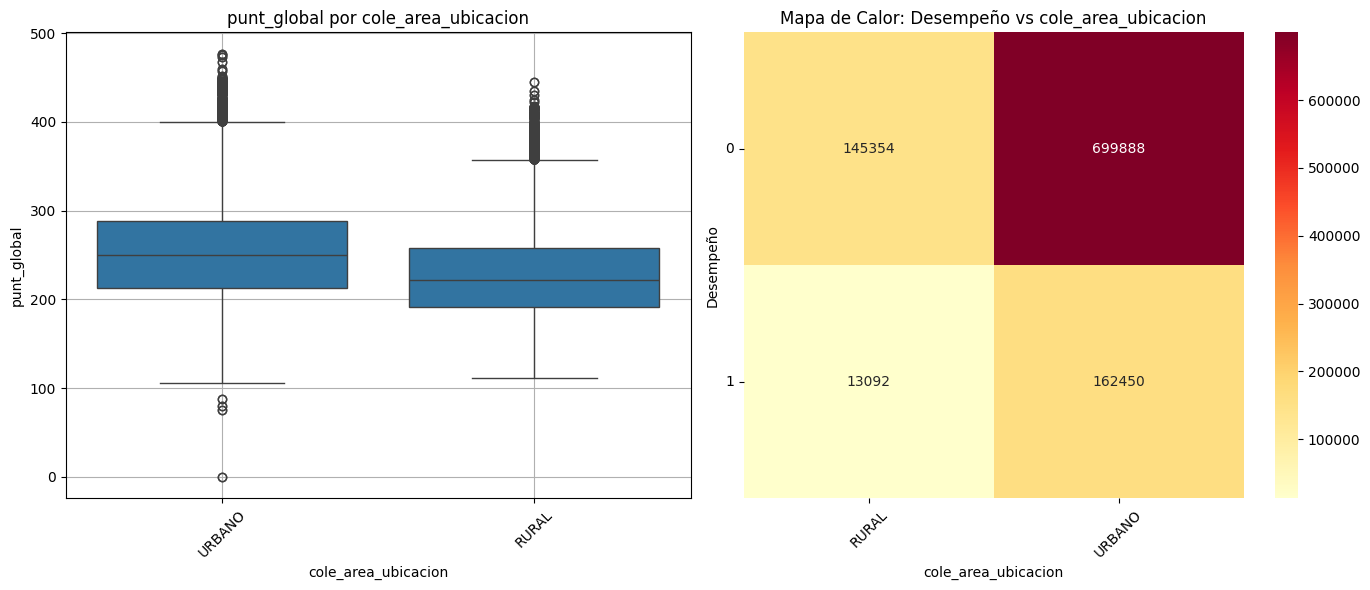

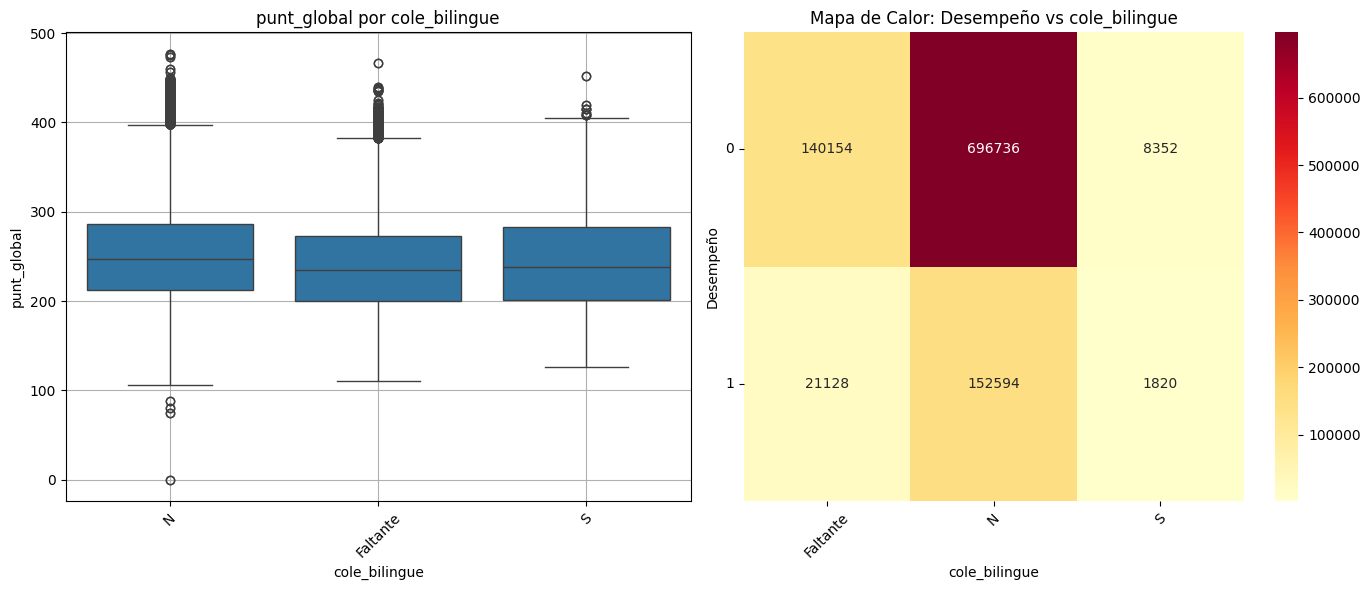

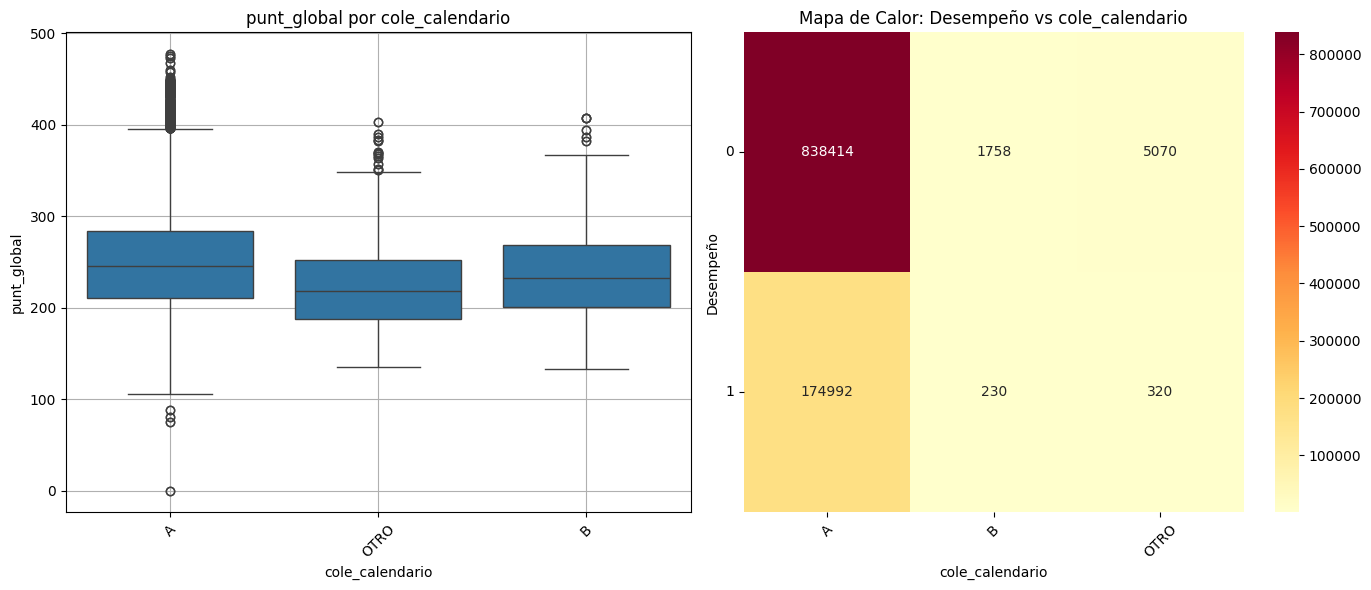

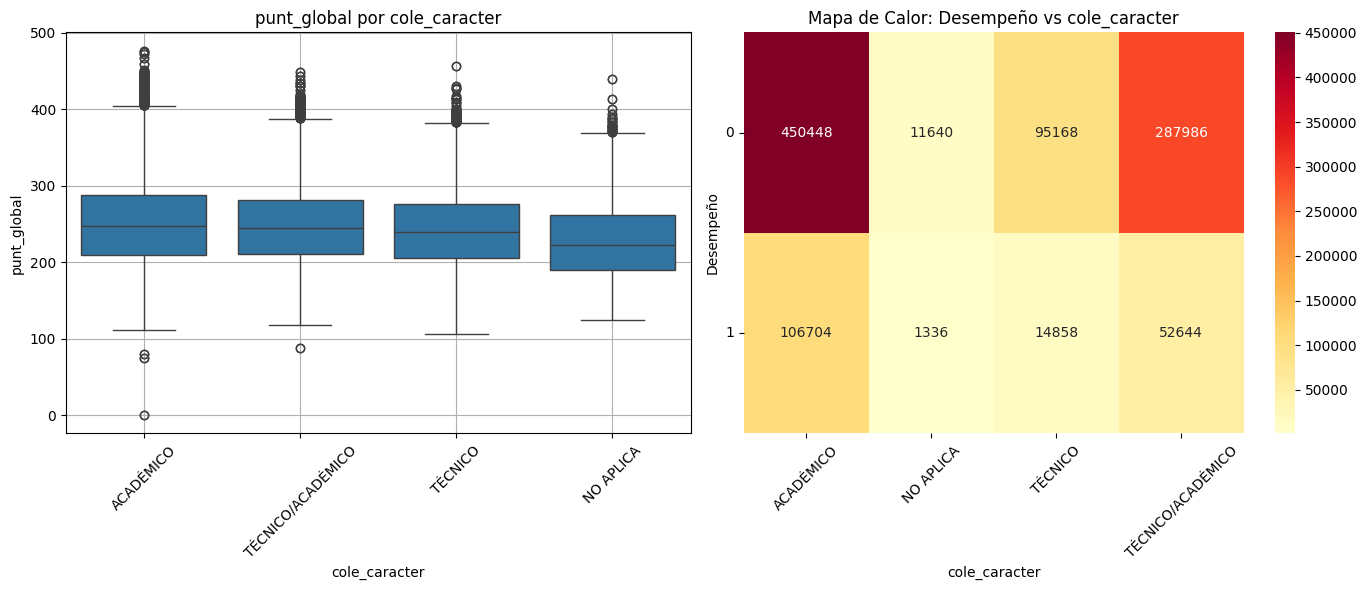

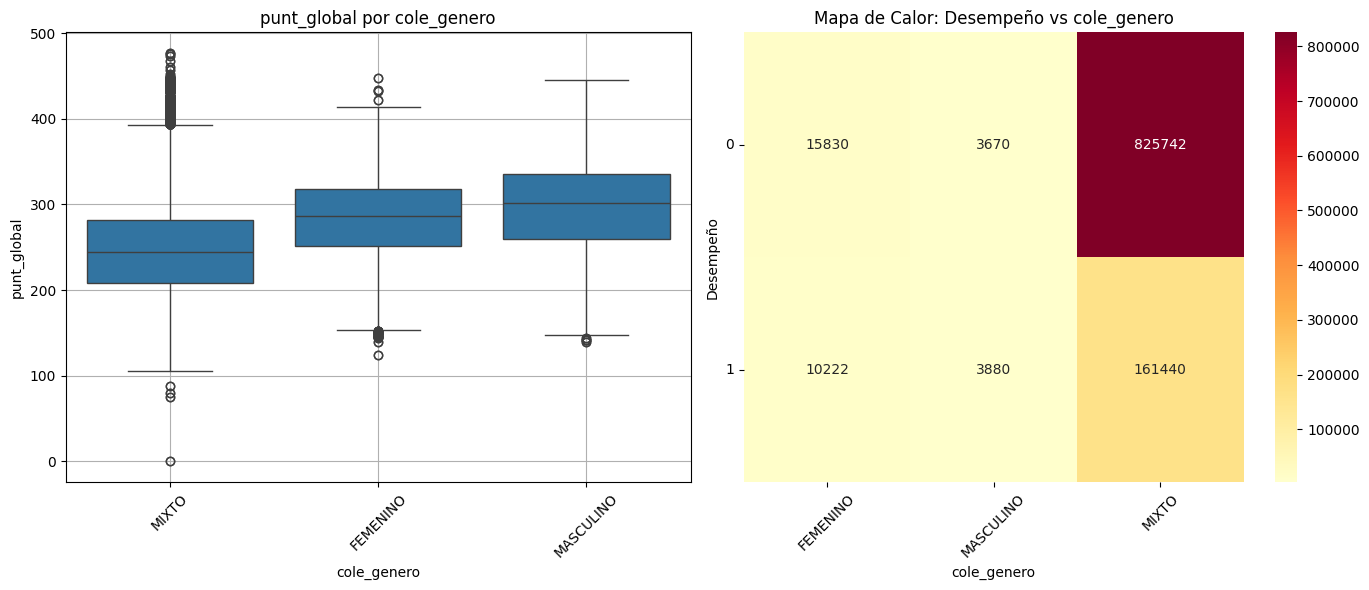

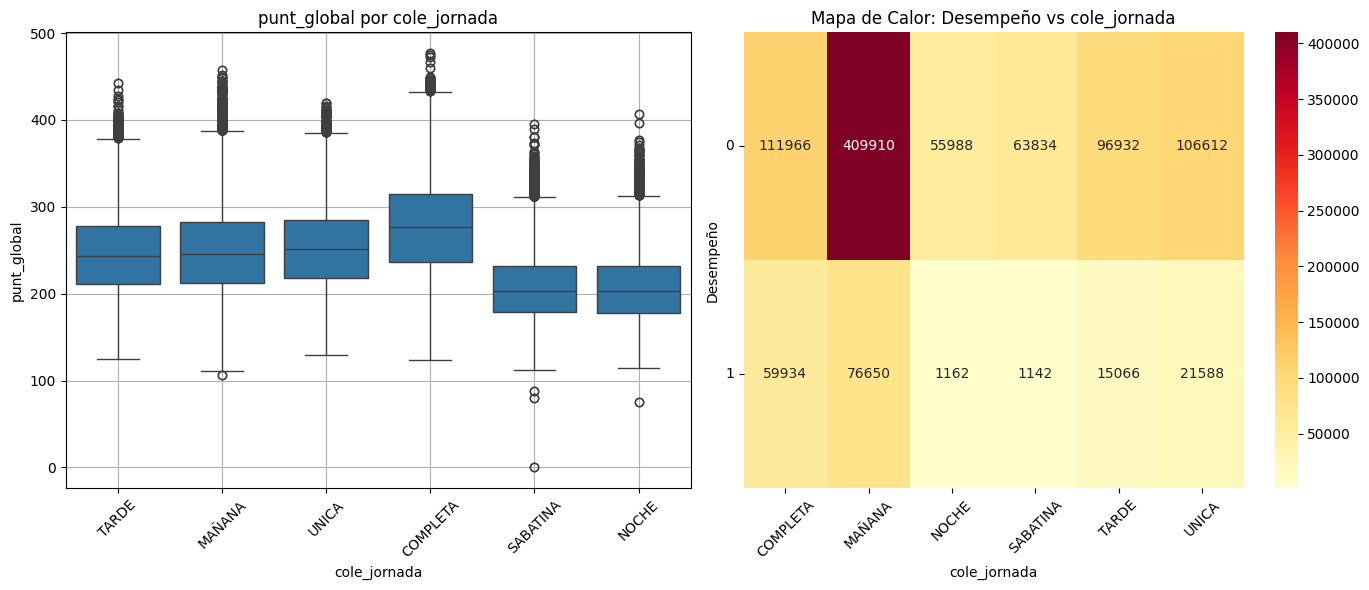

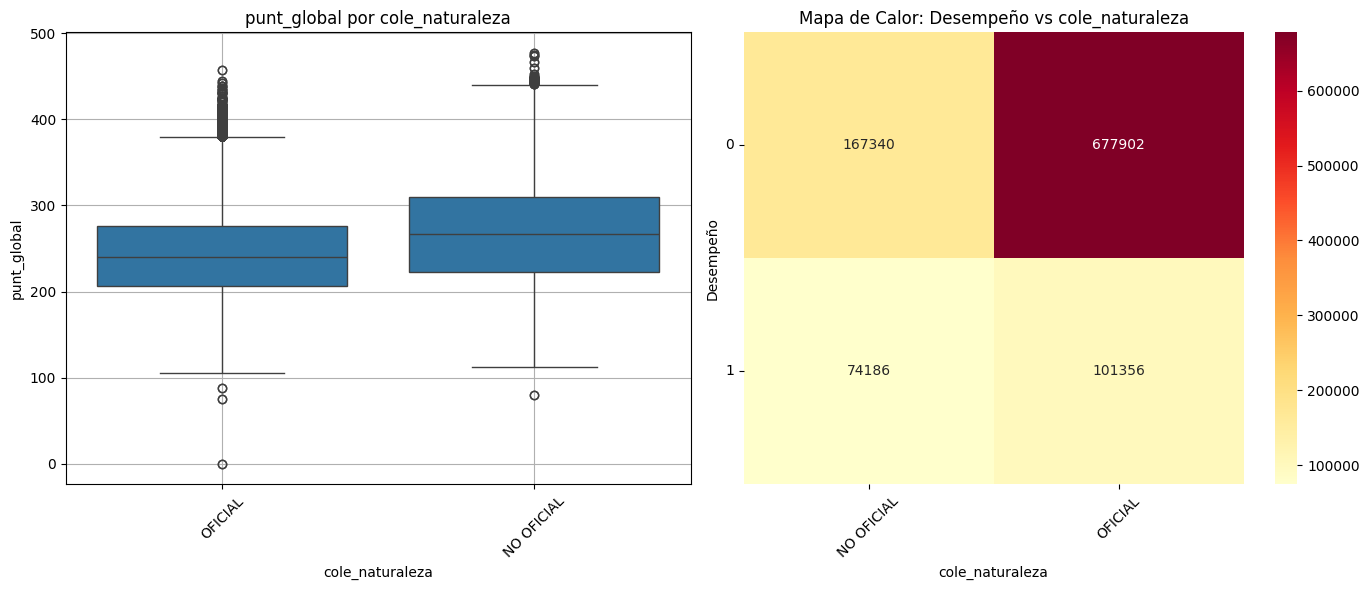

In [7]:
for col in var_cat_cole:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 fila, 2 columnas

    # Boxplot
    sns.boxplot(data=df2, x=col, y=target, ax=axes[0])
    axes[0].set_title(f'{target} por {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel(target)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True)

    # Heatmap
    tabla = pd.crosstab(df2['Ingresa'], df[col])
    sns.heatmap(tabla, annot=True, cmap='YlOrRd', fmt='d', ax=axes[1])
    axes[1].set_title(f'Mapa de Calor: Desempeño vs {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Desempeño")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()


#### Boxplots y mapas de calor entre las variables que corresponde a la familia

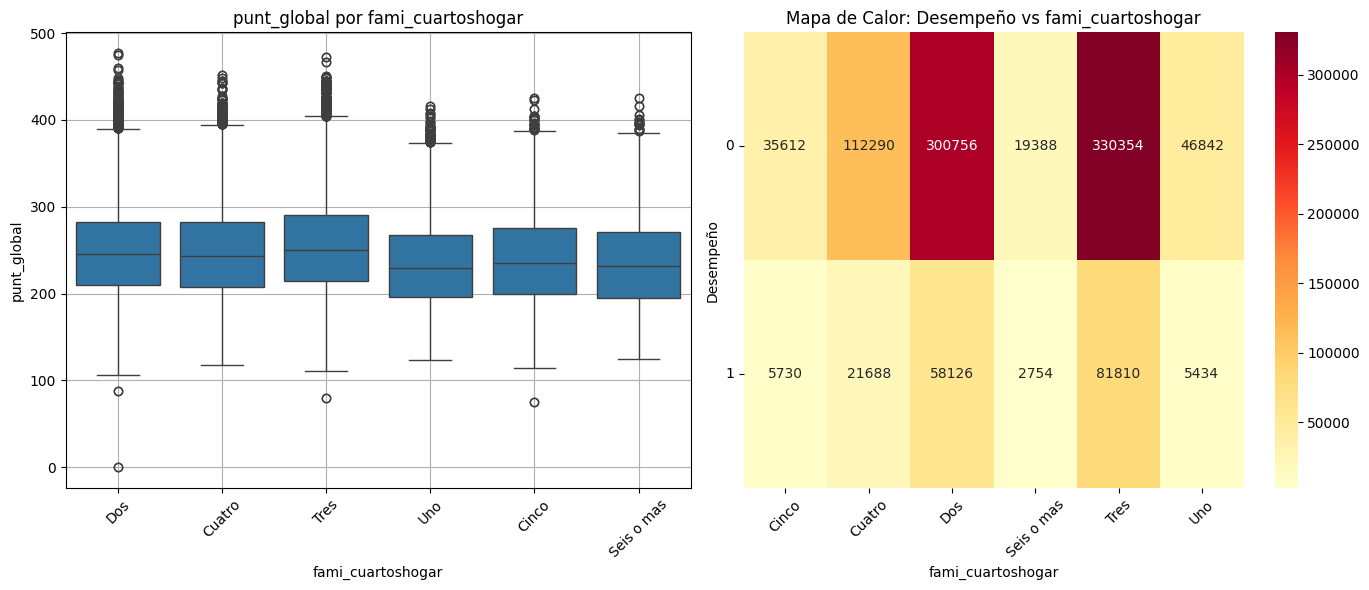

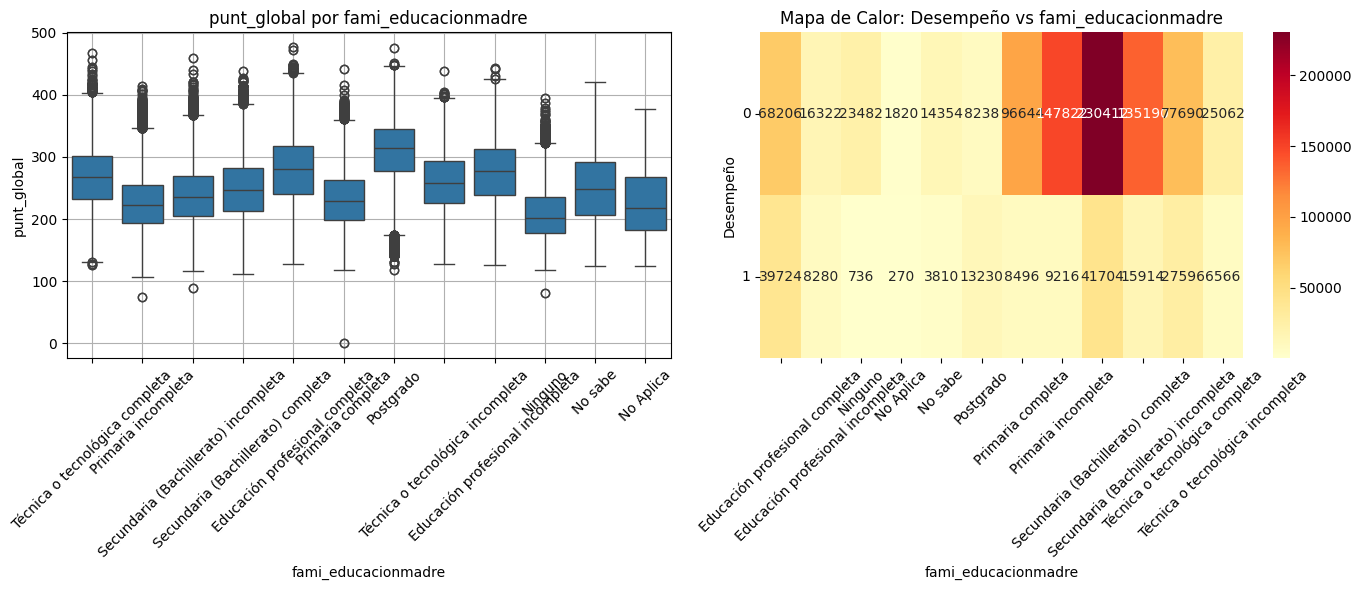

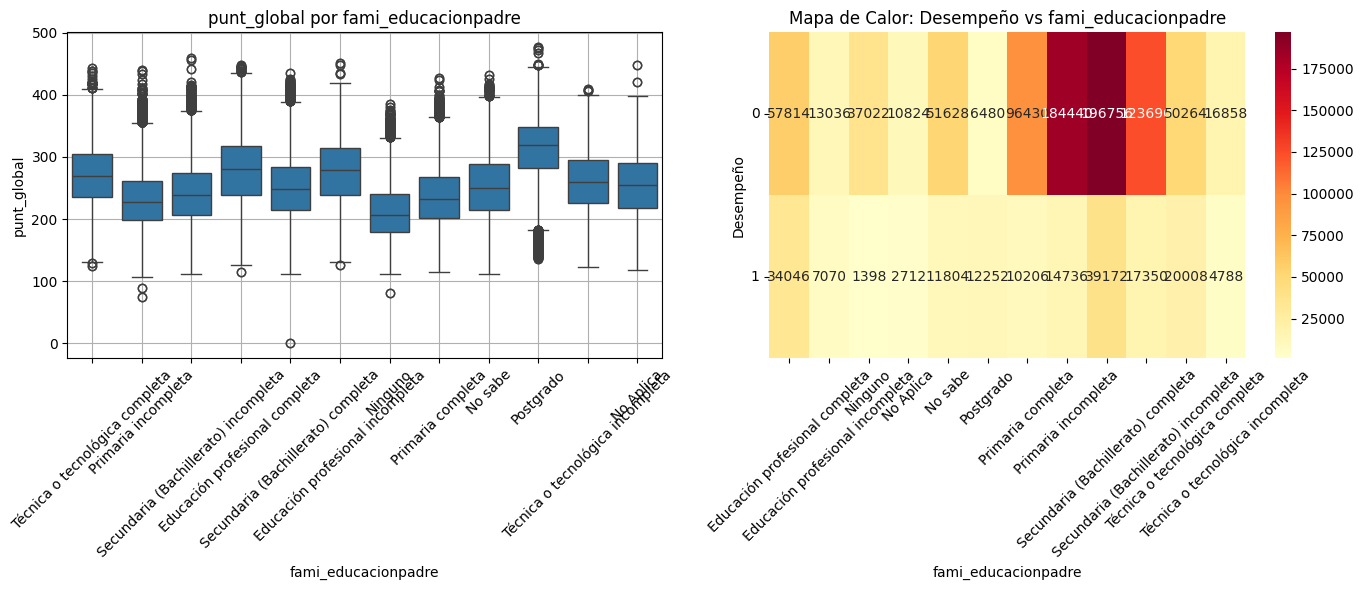

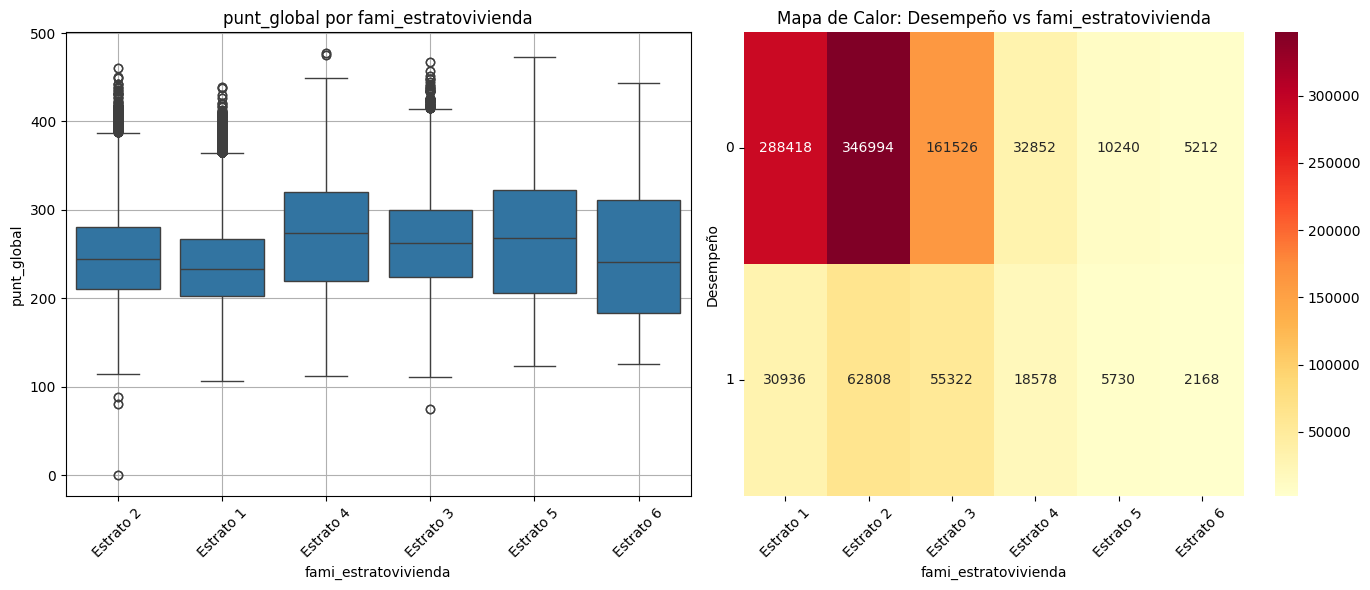

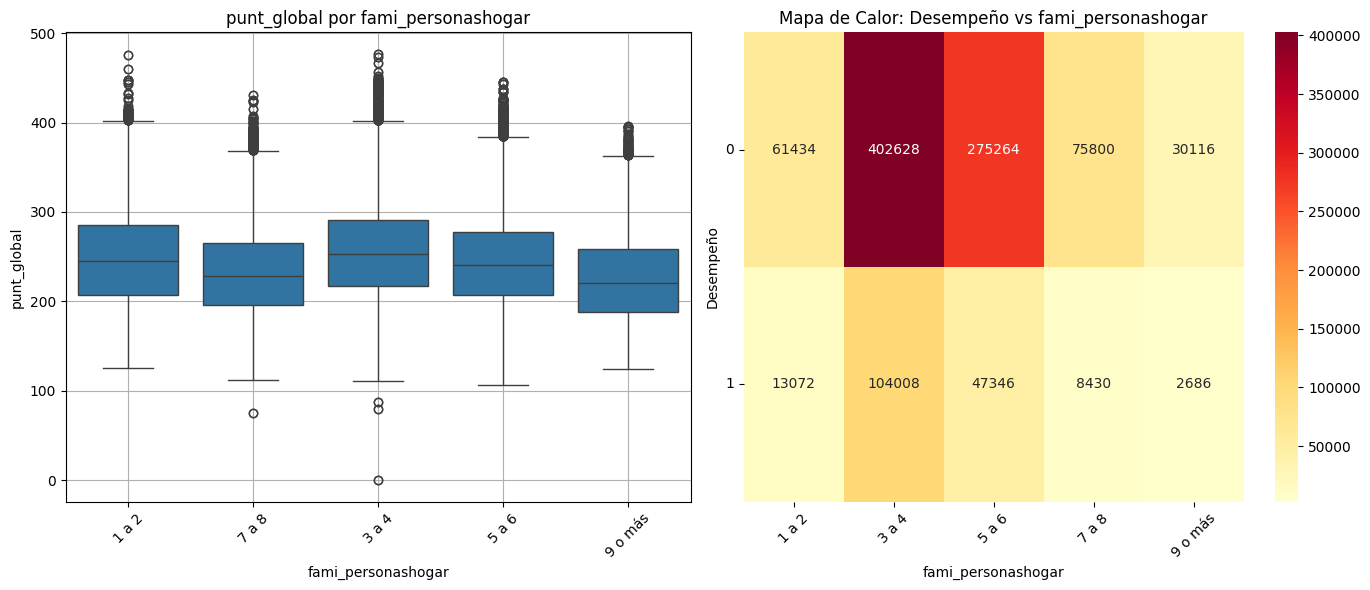

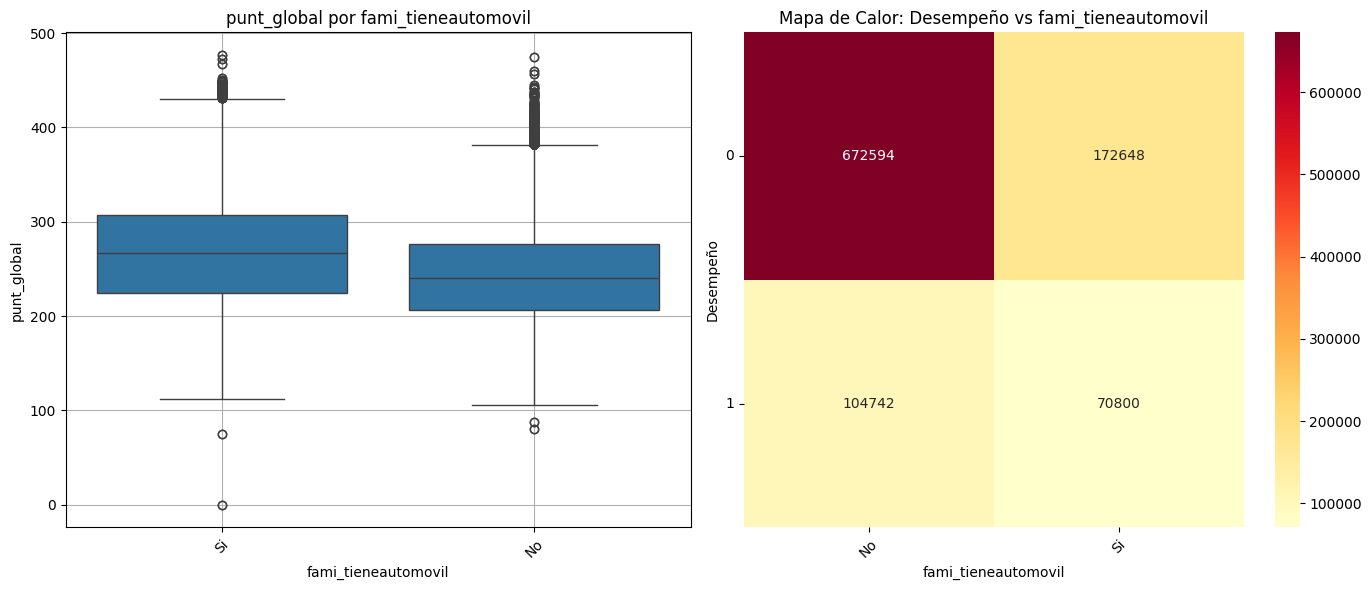

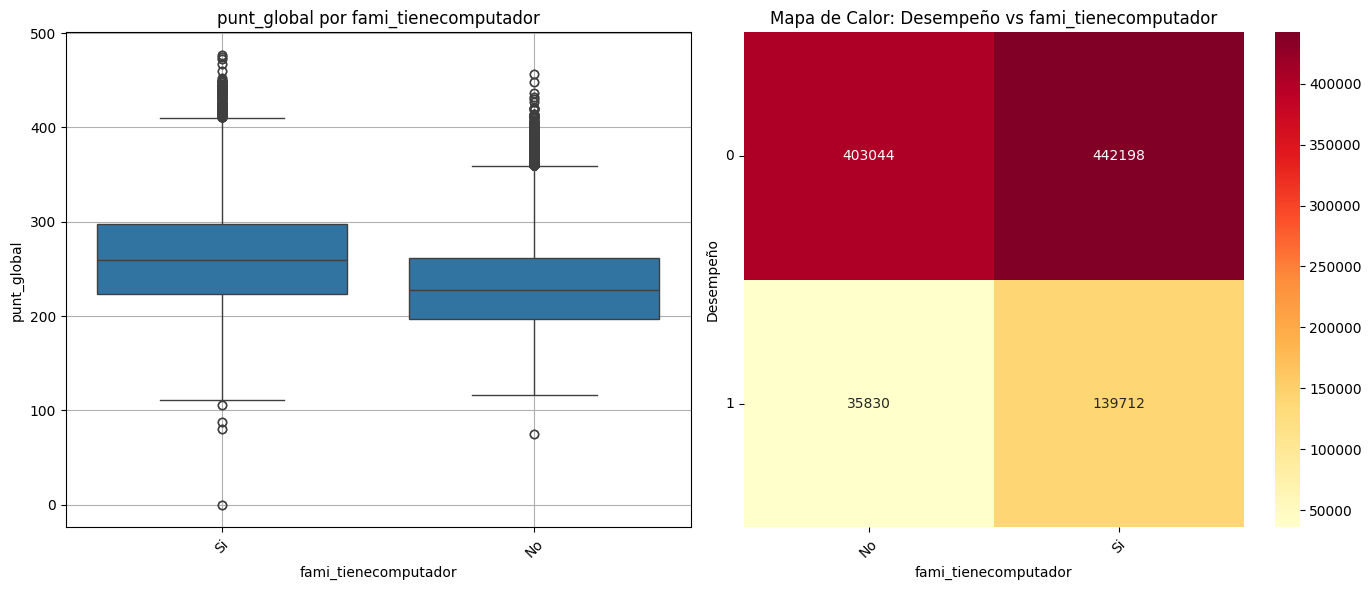

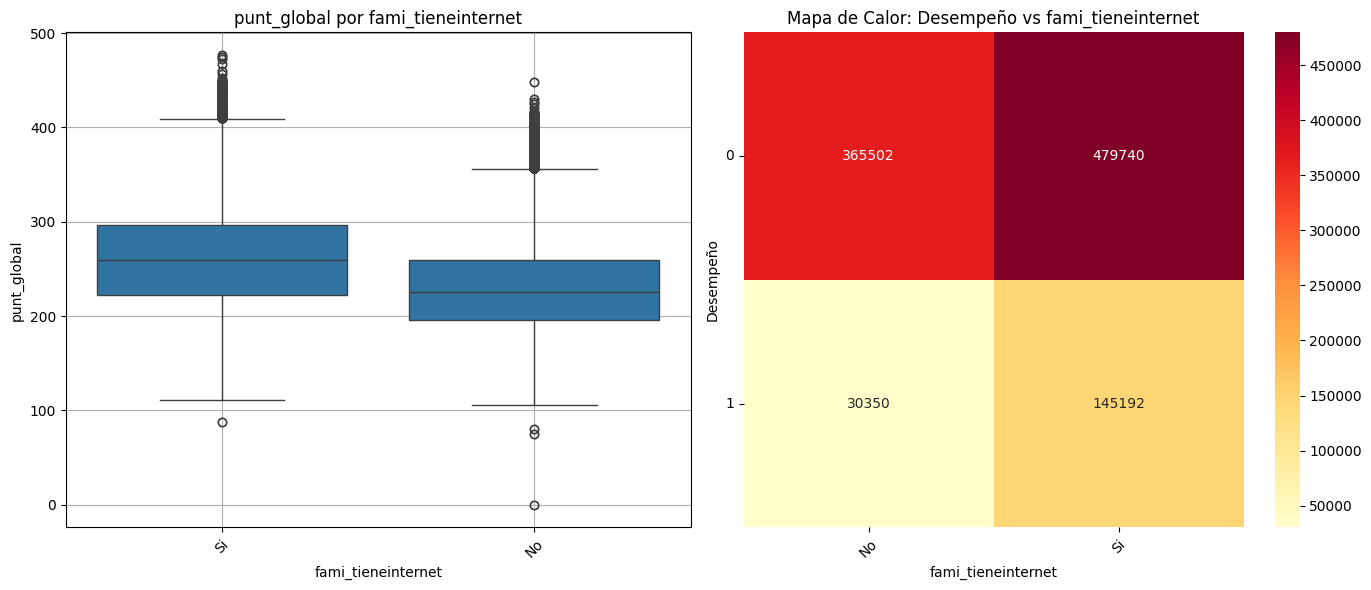

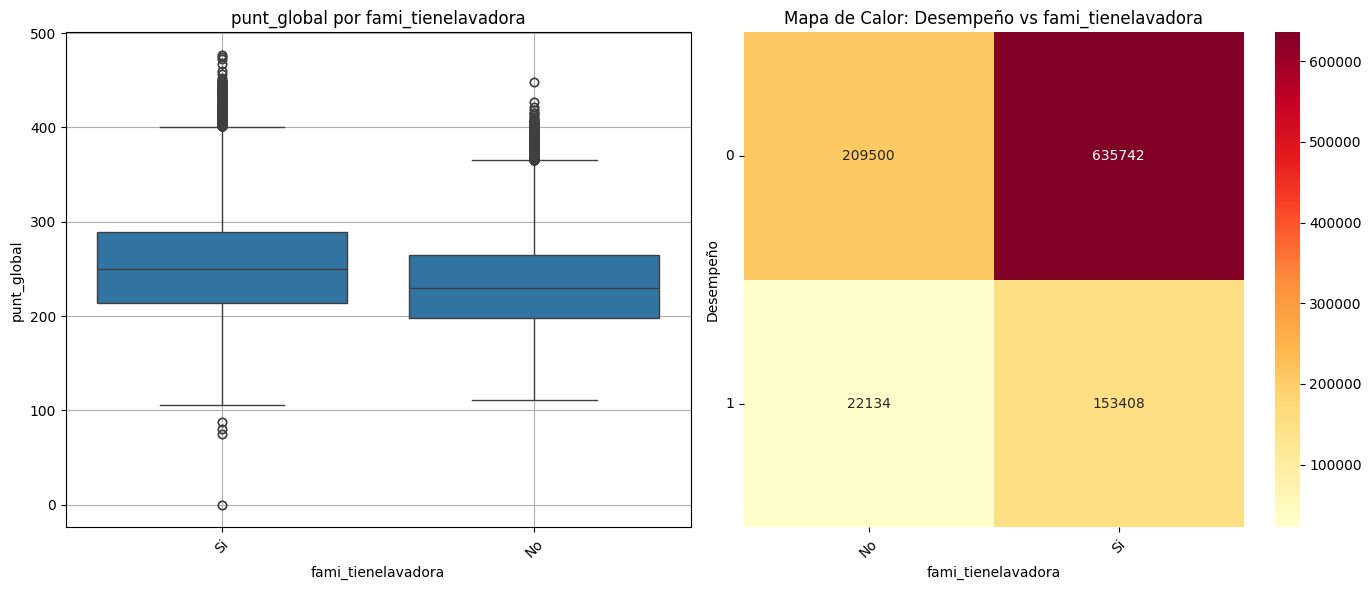

In [9]:
for col in var_cat_fami:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 fila, 2 columnas

    # Boxplot
    sns.boxplot(data=df2, x=col, y=target, ax=axes[0])
    axes[0].set_title(f'{target} por {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel(target)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True)

    # Heatmap
    tabla = pd.crosstab(df2['Ingresa'], df[col])
    sns.heatmap(tabla, annot=True, cmap='YlOrRd', fmt='d', ax=axes[1])
    axes[1].set_title(f'Mapa de Calor: Desempeño vs {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Desempeño")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()


#### Boxplots y mapas de calor entre las variables que corresponde al estudiante

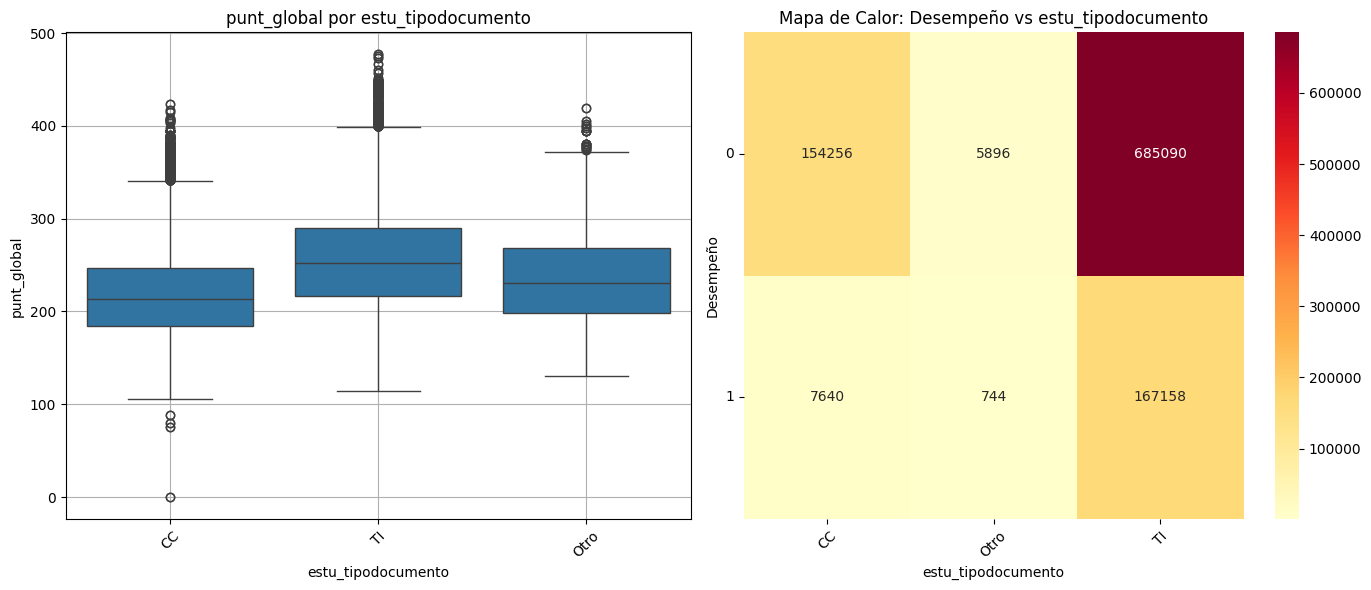

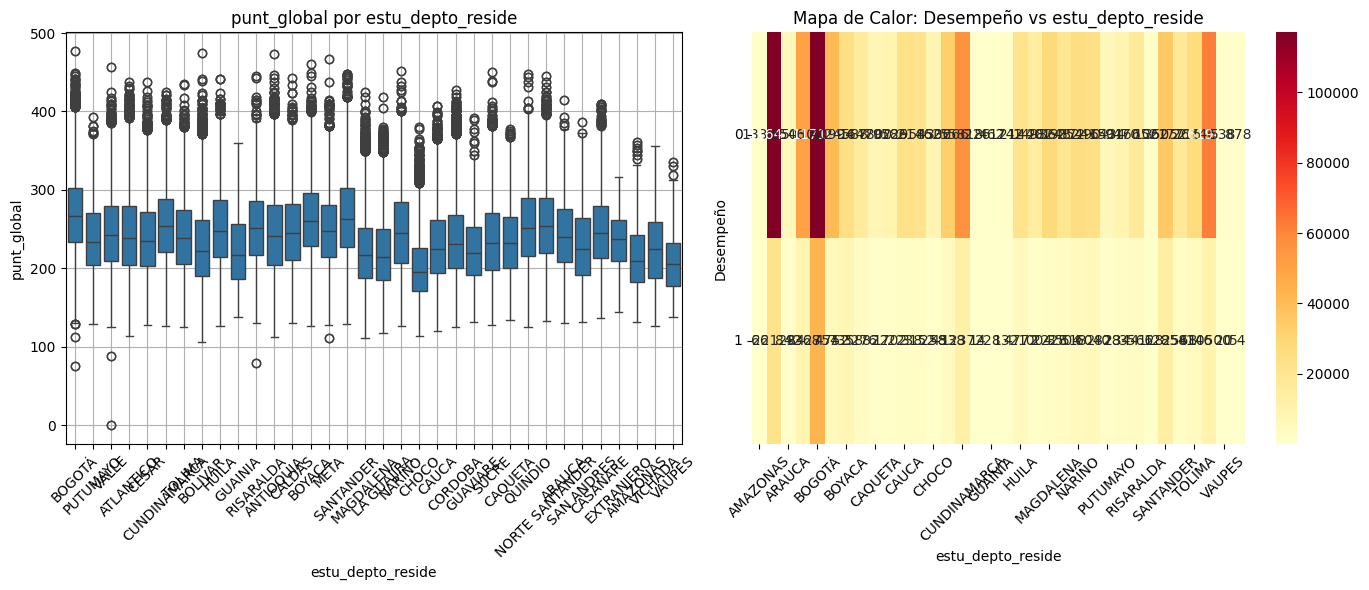

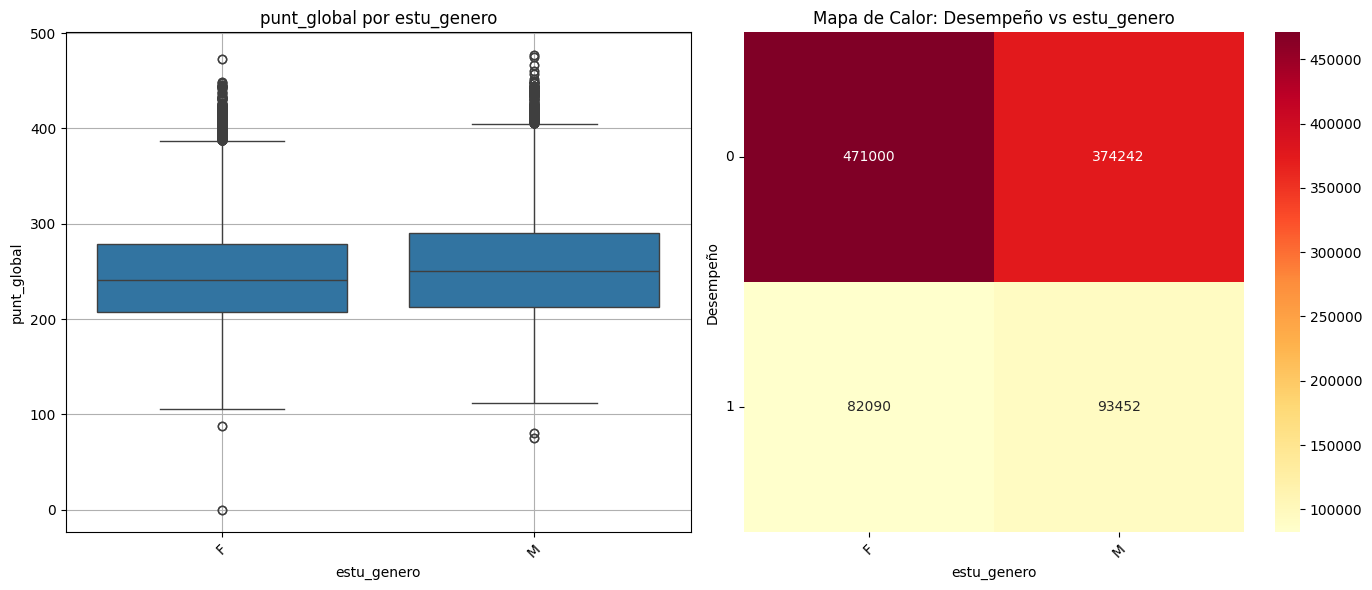

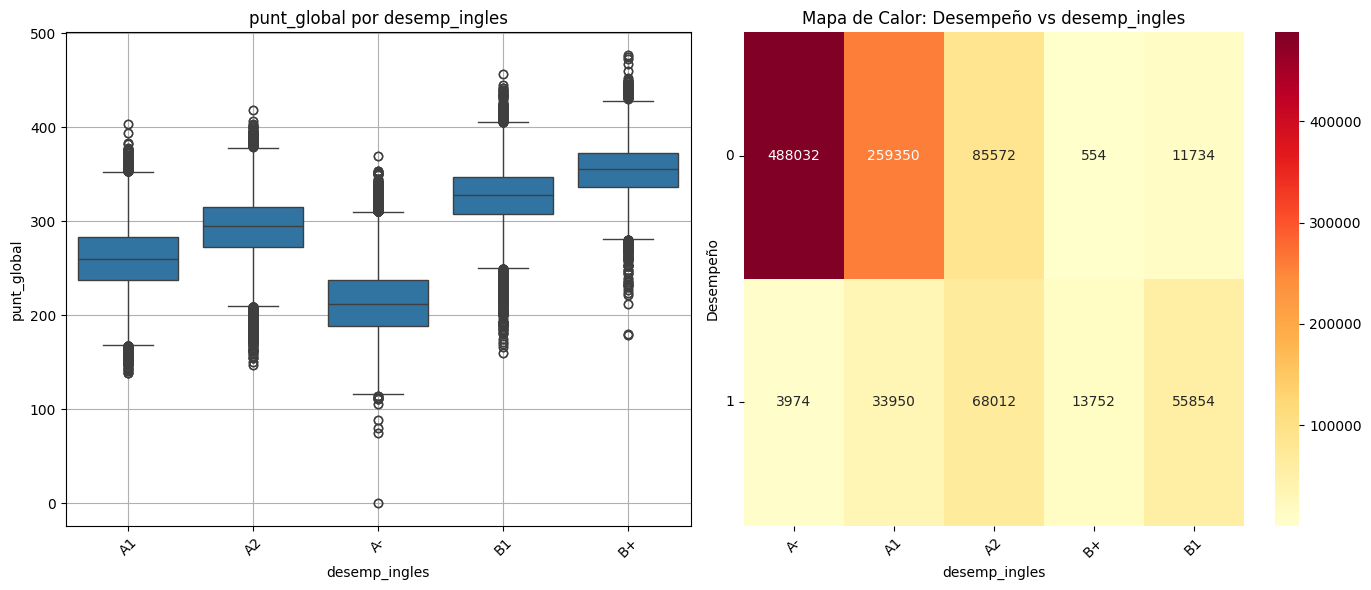

In [ ]:
for col in var_cat_estu:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 fila, 2 columnas

    # Boxplot
    sns.boxplot(data=df2, x=col, y=target, ax=axes[0])
    axes[0].set_title(f'{target} por {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel(target)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True)

    # Heatmap
    tabla = pd.crosstab(df2['Ingresa'], df[col])
    sns.heatmap(tabla, annot=True, cmap='YlOrRd', fmt='d', ax=axes[1])
    axes[1].set_title(f'Mapa de Calor: Desempeño vs {col}') #
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Desempeño")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()


In [ ]:
data = df2.copy()
data = data.drop(columns=['cole_bilingue', 'cole_caracter', 'punt_global'])

In [ ]:
model_data = data.copy()

#Exportar el dataframe limpio
model_data.to_csv("model_data.csv",index=False)
